/tmp/ipykernel_55/664195270.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="viridis")


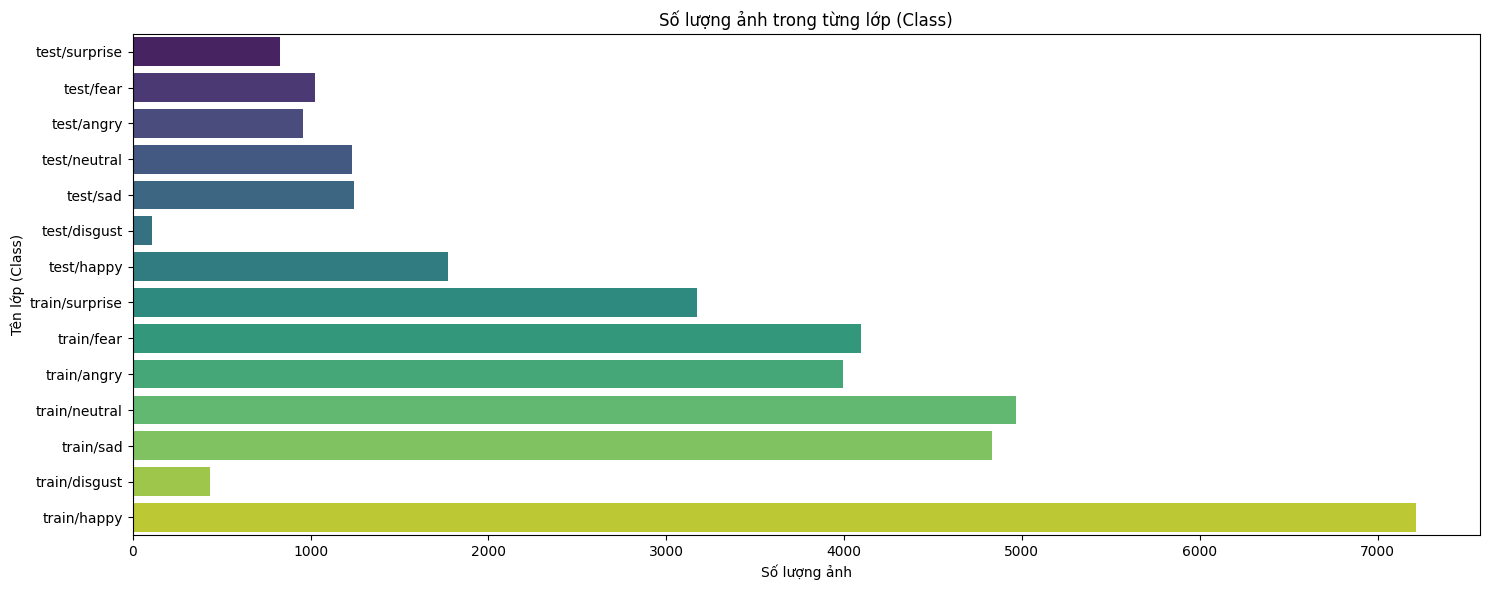

--- CHI TIẾT SỐ LƯỢNG ẢNH ---
Lớp test/surprise: 831 ảnh
Lớp test/fear: 1024 ảnh
Lớp test/angry: 958 ảnh
Lớp test/neutral: 1233 ảnh
Lớp test/sad: 1247 ảnh
Lớp test/disgust: 111 ảnh
Lớp test/happy: 1774 ảnh
Lớp train/surprise: 3171 ảnh
Lớp train/fear: 4097 ảnh
Lớp train/angry: 3995 ảnh
Lớp train/neutral: 4965 ảnh
Lớp train/sad: 4830 ảnh
Lớp train/disgust: 436 ảnh
Lớp train/happy: 7215 ảnh


In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

def get_image_counts(base_path):
    data_counts = {}
    for root, dirs, files in os.walk(base_path):
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(img_files) > 0:
            class_name = os.path.basename(root)
            parent_name = os.path.basename(os.path.dirname(root))

            if parent_name in ['train', 'test']:
                label = f"{parent_name}/{class_name}"
            else:
                label = class_name
                
            data_counts[label] = len(img_files)
    return data_counts

counts = get_image_counts('/kaggle/input')

labels = list(counts.keys())
values = list(counts.values())

sns.barplot(x=values, y=labels, palette="viridis")
plt.title('Số lượng ảnh trong từng lớp (Class)')
plt.xlabel('Số lượng ảnh')
plt.ylabel('Tên lớp (Class)')
plt.tight_layout()
plt.show()

print("--- CHI TIẾT SỐ LƯỢNG ẢNH ---")
for label, val in counts.items():
    print(f"Lớp {label}: {val} ảnh")

In [2]:
import os
import shutil
import random

# Định nghĩa các cảm xúc cần giữ lại cho bài toán lái xe
target_emotions = ['angry', 'happy', 'neutral', 'surprise']
max_images_per_class = 4000 # Giới hạn số ảnh tối đa mỗi class để tránh mất cân bằng

# Hàm tìm đường dẫn gốc của FER2013 
def find_fer_root(base_path='/kaggle/input'):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'test' in dirs and 'angry' in os.listdir(os.path.join(root, 'train')):
            return root
    return None

fer_root = find_fer_root()
working_dir = '/kaggle/working/Clean_FER2013'

if fer_root:
    print(f"Đã tìm thấy gốc FER2013 tại: {fer_root}")
    print("Bắt đầu lọc và cân bằng dữ liệu sang /kaggle/working...\n")
    
    # Tạo lại cấu trúc thư mục train/test trong thư mục làm việc
    for split in ['train', 'test']:
        for emotion in target_emotions:
            os.makedirs(os.path.join(working_dir, split, emotion), exist_ok=True)
            
            src_dir = os.path.join(fer_root, split, emotion)
            dest_dir = os.path.join(working_dir, split, emotion)
            
            if os.path.exists(src_dir):
                # Lấy danh sách toàn bộ ảnh
                images = os.listdir(src_dir)
                
                # Trộn ngẫu nhiên và cắt bớt nếu vượt quá max_images_per_class (chỉ áp dụng cho tập train)
                if split == 'train' and len(images) > max_images_per_class:
                    random.shuffle(images)
                    images = images[:max_images_per_class]
                    
                # Copy ảnh sang thư mục mới
                for img in images:
                    shutil.copy2(os.path.join(src_dir, img), os.path.join(dest_dir, img))
                
                print(f"Đã copy {len(images)} ảnh cho lớp {split}/{emotion}")
    
    print("\nHoàn tất!")
else:
    print("Không tìm thấy đường dẫn FER2013. Vui lòng kiểm tra lại cấu trúc thư mục input.")

Đã tìm thấy gốc FER2013 tại: /kaggle/input/datasets/msambare/fer2013
Bắt đầu lọc và cân bằng dữ liệu sang /kaggle/working...

Đã copy 3995 ảnh cho lớp train/angry
Đã copy 4000 ảnh cho lớp train/happy
Đã copy 4000 ảnh cho lớp train/neutral
Đã copy 3171 ảnh cho lớp train/surprise
Đã copy 958 ảnh cho lớp test/angry
Đã copy 1774 ảnh cho lớp test/happy
Đã copy 1233 ảnh cho lớp test/neutral
Đã copy 831 ảnh cho lớp test/surprise

Hoàn tất!
